<p align="left">
<img src="https://raw.githubusercontent.com/dewdotninja/exams/main/feng_heading_en.png" width=400 alt="Feng heading"/>
</p>

#### Department of Mechanical Engineering

### Class Project
Second Semester, Academic Year 2025

<br>**01208583 Robotics**

<hr>

**make by**
- Tammapon Numsarapatnuck 6714552394
- Kongsakul Tawaitian 6714552343

<hr>

**Problem number 4**

ผู้จัดทำเลือกหัวข้อที่4 คือการทำโจทย์ปัญหาข้อ 7-3 ใน [บทที่ 7](https://github.com/dewdotninja/ocrl/blob/main/doc/notebooks/chapter7.ipynb) คือ การหาแนววิถีเหมาะที่สุดแบบลูกผสมสำหรับขาหุ่นยนต์อย่างง่าย เรียกว่าหุ่นยนต์กระโดดขาเดี่ยว (one-legged hopper) ในระนาบ 2 มิติ เขียนโค้ดเพื่อหาแนววิถีเหมาะที่สุดโดยใช้ตัวแก้ปัญหาเช่น IPOPT และจำลองการกระโดดบน meshcat **ใช้ภาษาไพทอนเท่านั้น** ศึกษาเพิ่มเติมได้จาก [Lecture 17: Hybrid Systems and Legged Robots](https://youtu.be/QLyXkH4Jx1I?si=DnPL_NzIx4lix8jB) CMU16-745 (2025)

จากโจทย์ปัญหาข้อ 7-3

โจทย์ข้อนี้คือต้องการหาแนววิถีเหมาะที่สุดแบบลูกผสมสำหรับขาหุ่นยนต์อย่างง่าย เรียกว่าหุ่นยนต์กระโดดขาเดี่ยว (one-legged hopper) ในระนาบ 2 มิติดังแสดงในรูปที่ P7.1 โครงสร้างประกอบด้วยมวล $m$ ส่วนตัวหุ่นยนต์และส่วนเท้าที่สัมผัสพื้น กำหนดให้เท่ากันเพื่อทำให้ปัญหาง่ายขึ้น เมื่อหุ่นยนต์สัมผัสพื้น แรงเชิงเส้นในแนวขา $F$ จะผลักให้หุ่นยนต์ลอยขึ้นในอากาศ และใช้แรงบิด $t$ เพื่อปรับองศาของขาสำหรับการสัมผัสพื้นและกระโดดครั้งต่อไป

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/ocrl/refs/heads/main/doc/figs/ch7_hopper_1l.png" width=700 />
</div>
<div align="center">
รูปที่ P7.1 หุ่นยนต์กระโดดขาเดี่ยว
</div>

กำหนดสถานะเป็นตำแหน่งและความเร็วของกายและเท้าหุ่นยนต์ และตัวควบคุมคือแรงเชิงเส้นและแรงบิด
$$
x =
\left[\begin{array}{c}
r_b \\
r_f \\
v_b \\
v_f
\end{array}\right] \in \mathbb{R}^8, \;\;\;
u =
\left[\begin{array}{c}
F \\
\tau
\end{array}\right] \in \mathbb{R}^2 \tag{P7.1}
$$

กำหนดโหมดหมายเลข 1 และ 2 แทนภาวะที่หุ่นยนต์สัมผัสพื้น และลอยตัวเหนือพื้นตามลำดับ นิยามจัมพ์แมพสำหรับการเปลี่ยนผ่านระหว่างโหมด คือเมื่อเท้าสัมผัสพื้นให้ความเร็วในแนวดิ่งเป็นศูนย์ (เพื่อความง่ายจะไม่พิจารณาการลื่นไถลที่อาจเกิดขึ้น)
$$
x' = g_{21}(x) =
\left[\begin{array}{c}
r_b \\
r_f \\
v_b \\
0
\end{array}\right] \tag{P7.2}
$$
และจากเท้าสัมผัสพื้นสู่การลอยตัวในอากาศจะไม่มีการเปลี่ยนแปลงของสถานะในปัญหานี้ (เสมือนกับการคูณด้วยเมทริกซ์เอกลักษณ์)
$$
x' = g_{12}(x) = x \tag{P7.3}
$$
กำหนดแผนการกระโดดของหุ่นยนต์นี้เป็นการสลับระหว่างจุดเงื่อน โดยมีช่วงที่เท้าติดพื้นและช่วงลอยในอากาศจำนวนเท่ากับ N1 และ N2 ตามลำดับ บังคับเงื่อนไขดังนี้

<br>for k = 1:N1:
<br>&nbsp; &nbsp; $x_{k+1} = f_1(x_k,u_k)$
<br>&nbsp; &nbsp; $\phi(x) = 0$
<br>for k = (N1+1):N2:
<br>&nbsp; &nbsp; $x_{k+1} = f_2(x_k,u_k)$
<br>&nbsp; &nbsp; $\phi(x) \gt 0$
<br>$x_{N2} = g_{21}(x_{N2-1})$
<br>$\phi(x_{N2}) \gt 0$

ทำซ้ำตามจำนวนรอบการกระโดดที่ต้องการ

เขียนโค้ดเพื่อหาแนววิถีเหมาะที่สุดโดยใช้ตัวแก้ปัญหาเช่น IPOPT และจำลองการกระโดดบน meshcat

<hr>

### problem definition
หุ่นยนต์กระโดดขาเดี่ยว (one-legged hopper) เป็นระบบที่มีความซับซ้อนเนื่องจากมีลักษณะการทำงานแบบไฮบริด (Hybrid Dynamics) ซึ่งประกอบด้วยสภาวะที่เท้าสัมผัสพื้น (Stance Phase) และสภาวะที่ลอยตัวในอากาศ (Flight Phase)
โปรเจกต์นี้แก้ปัญหา **trajectory optimization** ของระบบกระโดดแบบ 2 มวล (body-foot) ภายใต้โหมดไฮบริด (stance/flight) โดยใช้:
- **JAX** สำหรับคำนวณอนุพันธ์อัตโนมัติ
- **cyipopt (IPOPT)** สำหรับแก้ nonlinear programming (NLP)
- **Matplotlib** สำหรับการแสดงผลเชิงกราฟ
- **MeshCat** สำหรับการจำลองในรูปแบบแอนิเมชัน


### Objective

- หาแนววิถีที่เหมาะที่สุด (hybrid optimal trajectory) สำหรับหุ่นยนต์กระโดดขาเดี่ยวในระนาบ 2 มิติ
โดยพิจารณา 2 โหมดการเคลื่อนที่: ช่วงเท้าสัมผัสพื้น (stance) และช่วงลอยตัว (flight) พร้อมเงื่อนไขการสลับโหมดด้วย jump map
จัดปัญหาเป็น optimization (ใช้ IPOPT) เพื่อหาลำดับสถานะ (x_k) และตัวควบคุม (u_k=[F,\tau]) ที่ดีที่สุดตามเงื่อนไขไดนามิกและข้อจำกัดการสัมผัสพื้น
- จำลองผลการกระโดดใน MeshCat

### Workflow
แผนภาพการทำงาน (Workflow Diagram) สามารถแบ่งออกเป็น 4 ส่วนหลัก คือ การตั้งค่าระบบ, การนิยามปัญหาทางคณิตศาสตร์, การประมวลผลด้วย Solver และการแสดงผลลัพธ์

<div align="center">
<img src="workflow diagram.png" width=700 />
</div>
<div align="center">
รูปที่ 1 workflow diagram
</div>


นำเข้าแพ็คเกจที่เกี่ยวข้อง

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
from cyipopt import Problem
import matplotlib.pyplot as plt
import meshcat
import meshcat.geometry as geo
import meshcat.transformations as tf
import time

### System Modeling
หุ่นยนต์ประกอบด้วยมวล 2 จุด ($m_1, m_2$) ในระบบพิกัด 2 มิติ ($x, y$) สถานะของระบบกำหนดด้วยเวกเตอร์ $x \in \mathbb{R}^8$:$$x = [r_{body}^x, r_{body}^y, r_{foot}^x, r_{foot}^y, v_{body}^x, v_{body}^y, v_{foot}^x, v_{foot}^y]^T$$พารามิเตอร์ระบบ:$m_{body} = 5.0$ kg, $m_{foot} = 1.0$ kgแรงโน้มถ่วง $g = 9.81$ m/s²ขีดจำกัดความยาวขา: $0.5 \le l \le 1.5$ เมตร

#### System and Discretization Settings

กำหนดมิติของสถานะและอินพุต: $N_x = 8$, $N_u = 2$

เวลารวมและ time step: $T_f = 4.4, h=0.1, N_t=\left\lceil \frac{T_f}{h}\right\rceil +1$

กำหนดช่วงโหมดไฮบริดด้วย $N_m$ และจำนวนโหมดรวม $N_{\text{modes}}$

พารามิเตอร์เชิงกายภาพ: $g=9.81,\quad m_1=5.0,\quad m_2=1.0,\quad l_{\min}=0.5,\quad l_{\max}=1.5$

In [ ]:
Nx, Nu = 8, 2
Tfinal, h = 4.4, 0.1
Nm = 5
Nt = int(np.ceil(Tfinal/h) + 1)
Nmodes = int(np.ceil(Nt/Nm))

g, m1, m2 = 9.81, 5.0, 1.0
l_min, l_max = 0.5, 1.5

#### Reference Trajectory Definition

สร้างวิถีอ้างอิง ใน form jnp สำหรับการใช้ JAX ในการคำนวน

$\mathbf{x}_{ref}\in\mathbb{R}^{N_x\times N_t}$ บนกริดเวลา:
$
t_k \in [0, T_f],\quad k=0,\dots,N_t-1
$

กำหนดตำแหน่งหลัก:
- body $x$: เคลื่อนที่เชิงเส้นจาก $-1$ ไป $1$
- body $y$: สัญญาณไซน์เพื่อจำลองการยกตัว
- foot $x$: เคลื่อนที่ตามแนวราบ

In [ ]:
ref_times = jnp.linspace(0, Tfinal, Nt)
xref = jnp.zeros((Nx, Nt))
xref = xref.at[0, :].set(jnp.linspace(-1.0, 1.0, Nt)) # x body
xref = xref.at[1, :].set(1.0 + 0.5 * jnp.sin(2 * jnp.pi / 10.0 * jnp.arange(Nt))) # y body
xref = xref.at[2, :].set(jnp.linspace(-1.0, 1.0, Nt)) # x foot

กำหนดความเร็วอ้างอิงแนวราบคงที่:
$
v_{x,\text{ref}}=\frac{2.0}{T_f}
$

และกำหนดแรง(input)อ้างอิง:
$
u_{\text{ref}}=\begin{bmatrix} m_1 g \\ 0 \end{bmatrix}
$
ซึ่งตีความว่าแรงแนวรัศมีชดเชยน้ำหนักหลัก และแรงแนวสัมผัสตั้งต้นเป็นศูนย์

In [ ]:
vx_ref = 2.0 / Tfinal
xref = xref.at[4, 1:-1].set(vx_ref)
xref = xref.at[6, 1:-1].set(vx_ref)
uref = jnp.array([m1 * g, 0.0])

### Dynamics & Integration
ใช้สมการการเคลื่อนที่ตามกฎของนิวตัน โดยในสภาวะลอยตัว (Flight Phase) แรงที่กระทำคือแรงโน้มถ่วงและแรงขับดันจากขา ($u$):$$\ddot{r}_{body} = \frac{1}{m_1} u - \begin{bmatrix} 0 \\ g \end{bmatrix}, \quad \ddot{r}_{foot} = -\frac{1}{m_2} u - \begin{bmatrix} 0 \\ g \end{bmatrix}$$

<div align="center">
<img src="freebody diagram.png" width=700 />
</div>
<div align="center">
รูปที่ 2 freebody diagram
</div>

เพื่อให้คอมพิวเตอร์ประมวลผลได้ ใช้การหาปริพันธ์แบบ Runge-Kutta 4th Order (RK4):

$k_1 = f(x_n, u_n)$

$k_2 = f(x_n + \frac{h}{2}k_1, u_n)$

$k_3 = f(x_n + \frac{h}{2}k_2, u_n)$

$k_4 = f(x_n + h k_3, u_n)$

$x_{n+1} = x_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$

#### Dynamics Model

แยกสถานะเป็นตำแหน่งและความเร็ว:
$
\mathbf{x}=\begin{bmatrix}\mathbf{r}_1\\\mathbf{r}_2\\\mathbf{v}\end{bmatrix},
\quad \mathbf{r}_1,\mathbf{r}_2\in\mathbb{R}^2,\; \mathbf{v}\in\mathbb{R}^4
$

นิยามทิศทางขา:
$
\boldsymbol{\ell}=\frac{\mathbf{r}_1-\mathbf{r}_2}{\|\mathbf{r}_1-\mathbf{r}_2\|}
$
แล้วสร้างเมทริกซ์ถ่ายแรง $\mathbf{B}$ ต่างกันตามโหมด `stance/flight`

สมการ:
$
\dot{\mathbf{x}}=
\begin{bmatrix}
\mathbf{v}\\
\mathbf{g}_{mode}+\mathbf{M}^{-1}\mathbf{B}\mathbf{u}
\end{bmatrix}
$

In [ ]:
def get_dynamics(x, u, mode):
    r1, r2, v = x[0:2], x[2:4], x[4:8]
    dist = jnp.linalg.norm(r1 - r2)
    l1 = (r1[0] - r2[0]) / dist
    l2 = (r1[1] - r2[1]) / dist

    # B matrix
    B_flight = jnp.array([[l1, l2], [l2, -l1], [-l1, -l2], [-l2, l1]])
    B_stance = jnp.array([[l1, l2], [l2, -l1], [0.0, 0.0], [0.0, 0.0]])
    B = jax.lax.cond(mode % 2 == 0, lambda _: B_stance, lambda _: B_flight, operand=None)

    m_inv = jnp.diag(jnp.array([1/m1, 1/m1, 1/m2, 1/m2]))
    gravity = jnp.array([0, -g, 0, -g if mode % 2 != 0 else 0])
    vdot = gravity + m_inv @ (B @ u)
    return jnp.concatenate([v, vdot])

#### RK4 Time Integration

ใช้ Runge–Kutta 4th order เพื่อประมาณสถานะถัดไป:
$
\mathbf{x}_{k+1}=\mathbf{x}_k+\frac{h}{6}\left(\mathbf{k}_1+2\mathbf{k}_2+2\mathbf{k}_3+\mathbf{k}_4\right)
$
โดย $\mathbf{k}_i$ ได้จากพลวัตที่จุดย่อยในช่วงเวลาเดียวกัน

In [ ]:
def rk4_step(x, u, mode):
    f = lambda _x: get_dynamics(_x, u, mode)
    k1 = f(x)
    k2 = f(x + 0.5 * h * k1)
    k3 = f(x + 0.5 * h * k2)
    k4 = f(x + h * k3)
    return x + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

### Optimization Formulation

นิยามปัญหาให้อยู่ในรูป:$$\min_{z} J(z) \quad \text{subject to} \quad g(z) = 0, \quad h(z) \le 0$$**ฟังก์ชันเป้าหมาย (Objective Function)**:ลดความคลาดเคลื่อนจากเป้าหมายและลดการใช้พลังงาน:$$J = \sum_{k=0}^{N} \|x_k - x_{ref}\|^2_Q + \|u_k\|^2_R$$**ข้อจำกัด (Constraints)**:
- Dynamic Consistency: $x_{k+1} = \text{step}(x_k, u_k)$
- Leg Length: $l_{min}^2 \le \|r_{body} - r_{foot}\|^2 \le l_{max}^2$
- Ground Constraint: $r_{foot}^y \ge 0$

#### NLP Decision Vector Structure

เวกเตอร์ตัดสินใจ:
$
\mathbf{z}=[\mathbf{x}_0,\mathbf{u}_0,\mathbf{x}_1,\mathbf{u}_1,\dots,\mathbf{x}_{N_t-2},\mathbf{u}_{N_t-2},\mathbf{x}_{N_t-1}]
$
ขนาดรวม:
$
n_{nlp}=N_tN_x+(N_t-1)N_u
$

ฟังก์ชัน `unpack_z` ใช้ถอด $\mathbf{z}$ กลับเป็นเมทริกซ์สถานะ $\mathbf{X}$ และอินพุต $\mathbf{U}$

In [ ]:
def unpack_z(z):
    # z: [x0, u0, x1, u1, ..., x(Nt-1), u(Nt-1), xNt]
    # ขนาด n_nlp = Nt*Nx + (Nt-1)*Nu
    X = []
    U = []
    idx = 0
    for i in range(Nt - 1):
        X.append(z[idx : idx + Nx])
        U.append(z[idx + Nx : idx + Nx + Nu])
        idx += Nx + Nu
    X.append(z[idx : idx + Nx])
    return jnp.array(X).T, jnp.array(U).T

กำหนดฟังก์ชันเป้าหมายแบบ quadratic:

$
J=\sum_{k=0}^{N_t-2}\frac{1}{2}\left(
(\mathbf{x}_k-\mathbf{x}_{ref,k})^\top\mathbf{Q}(\mathbf{x}_k-\mathbf{x}_{ref,k})
+(\mathbf{u}_k-\mathbf{u}_{ref})^\top\mathbf{R}(\mathbf{u}_k-\mathbf{u}_{ref})
\right)
+\frac{1}{2}(\mathbf{x}_f-\mathbf{x}_{ref,f})^\top\mathbf{Q}(\mathbf{x}_f-\mathbf{x}_{ref,f})
$

โดยในโค้ดใช้ $\mathbf{Q}=\mathbf{I}$, $\mathbf{R}=10^{-3}\mathbf{I}$


In [ ]:
def objective(z):
    X, U = unpack_z(z)
    cost = 0.0
    Q = jnp.eye(Nx)
    R = 0.001 * jnp.eye(Nu)
    for k in range(Nt - 1):
        err_x = X[:, k] - xref[:, k]
        err_u = U[:, k] - uref
        cost += 0.5 * (err_x.T @ Q @ err_x + err_u.T @ R @ err_u)
    err_xf = X[:, -1] - xref[:, -1]
    cost += 0.5 * (err_xf.T @ Q @ err_xf)
    return cost

ข้อจำกัดประกอบด้วย:
1. Initial/terminal:
$
\mathbf{x}_0=\mathbf{x}_{ref,0},\quad \mathbf{x}_{N_t-1}=\mathbf{x}_{ref,N_t-1}
$
2. Dynamics:
$
\mathbf{x}_{k+1}=\mathrm{RK4}(\mathbf{x}_k,\mathbf{u}_k,\text{mode}_k)
$
3. Stance foot-height:
$
y_{foot}(k)=0 \;\; (\text{เฉพาะ stance})
$
4. Leg length bounds:
$
l_{min}^2 \le \|\mathbf{r}_{1,k}-\mathbf{r}_{2,k}\|^2 \le l_{max}^2
$

มี jump map (inelastic collision) ตอนจบรอบ flight โดยรีเซ็ตบางความเร็วให้เป็นศูนย์

In [ ]:
def constraints(z):
    X, U = unpack_z(z)
    cons = []

    # 1. Initial & Terminal
    cons.append(X[:, 0] - xref[:, 0])
    cons.append(X[:, -1] - xref[:, -1])

    # 2. Dynamics & Stance (y_foot=0)
    for k in range(Nt - 1):
        mode = k // Nm
        is_last_step_of_flight = (mode % 2 != 0) and ((k+1) % Nm == 0)

        x_next_sim = rk4_step(X[:, k], U[:, k], mode)

        # Inelastic collision jump map
        if is_last_step_of_flight:
            x_next_sim = x_next_sim.at[6:].set(0.0)

        cons.append(x_next_sim - X[:, k+1])

        # Stance constraint: foot y=0
        if mode % 2 == 0:
            cons.append(jnp.array([X[3, k]]))

    # 3. Leg length bounds (เป็น Inequality แต่ออกแบบเป็น Equality - l ในช่วงที่กำหนด)
    # ใน cyipopt เราจะส่งค่าเหล่านี้ไปเช็คที่ bounds ของ constraint แทน
    for k in range(Nt):
        length_sq = jnp.sum((X[0:2, k] - X[2:4, k])**2)
        cons.append(jnp.array([length_sq]))

    return jnp.concatenate(cons)

#### JAX AD + JIT

ใช้ JAX เพื่อคำนวณอนุพันธ์อัตโนมัติ:
$
\nabla J(\mathbf{z}),\quad \mathbf{J}_c(\mathbf{z})=\frac{\partial \mathbf{c}}{\partial \mathbf{z}}
$
และใช้ `jit` เพื่อเร่งความเร็วการประเมินซ้ำภายใน IPOPT

In [ ]:
# JAX Differentiation
jit_obj = jax.jit(objective)
jit_grad = jax.jit(jax.grad(objective))
jit_cons = jax.jit(constraints)
jit_jac = jax.jit(jax.jacobian(constraints))

คลาส `HopperProblem` ทำหน้าที่เป็น interface ให้ IPOPT เรียก:
- objective
- gradient
- constraints
- jacobian

มีการแปลงผลลัพธ์จาก JAX array เป็น NumPy array เพื่อความเข้ากันได้กับ `cyipopt`

In [ ]:
class HopperProblem:
    def objective(self, z): return np.array(jit_obj(z))
    def gradient(self, z):  return np.array(jit_grad(z))
    def constraints(self, z): return np.array(jit_cons(z))
    def jacobian(self, z): return np.array(jit_jac(z))

#### Constraint Bounds and Problem Initialization

ประเมินจำนวน constraints จริงจาก `c_sample` แล้วสร้าง:
$
\mathbf{c}_L,\mathbf{c}_U
$
โดย constraints ช่วงท้ายเป็น leg-length และกำหนดเป็น inequality bounds:
$
c_L=l_{min}^2,\quad c_U=l_{max}^2
$

In [ ]:
# ตั้งค่า Bounds
n_nlp = Nt * Nx + (Nt - 1) * Nu
z0 = np.zeros(n_nlp) # ควรใช้ guess จาก xref

# คำนวณจำนวน Constraints เพื่อตั้งค่า Lower/Upper Bounds (cl, cu)
c_sample = jit_cons(z0)
m_nlp = len(c_sample)
cl = np.zeros(m_nlp)
cu = np.zeros(m_nlp)

# ปรับ bounds สำหรับ leg length (ช่วงท้ายของ constraints vector)
# ต้องนับ index ให้แม่นยำตามการ append ในฟังก์ชัน constraints
leg_cons_start_idx = m_nlp - Nt
cl[leg_cons_start_idx:] = l_min**2
cu[leg_cons_start_idx:] = l_max**2

สร้างออบเจกต์ `Problem` ด้วยข้อมูล:
- จำนวนตัวแปร $n$
- จำนวน constraints $m$
- bounds ของตัวแปรและ constraints
- callback object

$
\texttt{Problem}(n,m,\text{callbacks},\mathbf{lb},\mathbf{ub},\mathbf{cl},\mathbf{cu})
$

In [ ]:
prob = Problem(
    n=n_nlp,
    m=m_nlp,
    problem_obj=HopperProblem(),
    lb=-np.inf * np.ones(n_nlp),
    ub=np.inf * np.ones(n_nlp),
    cl=cl,
    cu=cu
)

#### Initialization Strategy

กำหนดค่าเริ่มต้นจาก reference + noise:
$
\mathbf{X}^{(0)}=\mathbf{X}_{ref}+\epsilon_x,\quad
\mathbf{U}^{(0)}=\mathbf{U}_{ref}+\epsilon_u
$
แล้ว pack กลับเป็น $\mathbf{z}_0$

การมี initial guess ที่ดีช่วยให้ convergence เร็วขึ้นและลดโอกาสติด local minima ที่ไม่เหมาะสม

In [ ]:
# --- การสร้าง Initial Guess (z0) ---
# โครงสร้าง z: [x0, u0, x1, u1, ..., x(Nt-2), u(Nt-2), x(Nt-1)]
# หมายเหตุ: เสุ่ม Noise เข้าไป 0.1
xguess = np.array(xref) + 0.1 * np.random.randn(Nx, Nt)
uguess = np.tile(uref.reshape(-1, 1), (1, Nt-1)) + 0.1 * np.random.randn(Nu, Nt-1)

z0_list = []
for k in range(Nt - 1):
    z0_list.append(xguess[:, k])
    z0_list.append(uguess[:, k])
z0_list.append(xguess[:, -1])

z0 = np.concatenate(z0_list)

#### Solver Configuration and Optimization Run

ตั้งค่า tolerances และจำนวนรอบสูงสุด:
$
\text{tol}=10^{-6},\quad \text{constr\_viol\_tol}=10^{-6}
$
เลือก `limited-memory` สำหรับ Hessian approximation (L-BFGS)

จากนั้นแก้ปัญหาเพื่อหา:
$
\mathbf{z}^\star=\arg\min J(\mathbf{z})\;\text{s.t.}\; \mathbf{c}_L\le \mathbf{c}(\mathbf{z})\le \mathbf{c}_U
$

In [ ]:
# --- การเรียกใช้งาน Solver ---
# กำหนดค่าพารามิเตอร์สำหรับ Ipopt
prob.add_option('tol', 1e-6)
prob.add_option('constr_viol_tol', 1e-6)
prob.add_option('max_iter', 1000)
prob.add_option('hessian_approximation', 'limited-memory') # ใช้ L-BFGS แทนการหา Hessian จริง

print("Starting solver...")
z_sol, info = prob.solve(z0)

print(f"Solver Status: {info['status_msg']}")

Starting solver...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:   175616
Number of nonzeros in inequality constraint Jacobian.:    20160
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      448
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      392
Total num

ตรวจสอบค่า Total Cost สุดท้าย

In [ ]:
total_cost = info['obj_val']
print(f"Total Cost is: {total_cost}")

Total Cost is: 113.9280014038086


#### Unpacking Optimized Solution

หลัง solve สำเร็จ ทำการถอด $\mathbf{z}^\star$ เป็น:
$
\mathbf{X}^\star\in\mathbb{R}^{N_x\times N_t},\quad
\mathbf{U}^\star\in\mathbb{R}^{N_u\times (N_t-1)}
$
พร้อมสร้างแกนเวลาเพื่อใช้พล็อตผล

In [ ]:
def post_process(z_sol):
    X_list = []
    U_list = []
    idx = 0
    for i in range(Nt - 1):
        X_list.append(z_sol[idx : idx + Nx])
        U_list.append(z_sol[idx + Nx : idx + Nx + Nu])
        idx += Nx + Nu
    X_list.append(z_sol[idx : idx + Nx])
    return np.array(X_list).T, np.array(U_list).T

xtraj_sol, utraj_sol = post_process(z_sol)
time_axis = np.linspace(0, Tfinal, Nt)

#### Result Plots

นำเสนอผลลัพธ์จากการรัน Solver Ipopt พบว่าระบบสามารถเข้าสู่จุดที่เหมาะสมที่สุด (Optimal Solution) โดยมีรายละเอียดดังนี้:
1. ความสูง \(y_1, y_2\)
2. ตำแหน่งแนวราบ \(x_1, x_2\)
3. แรงควบคุม \(u_1, u_2\)

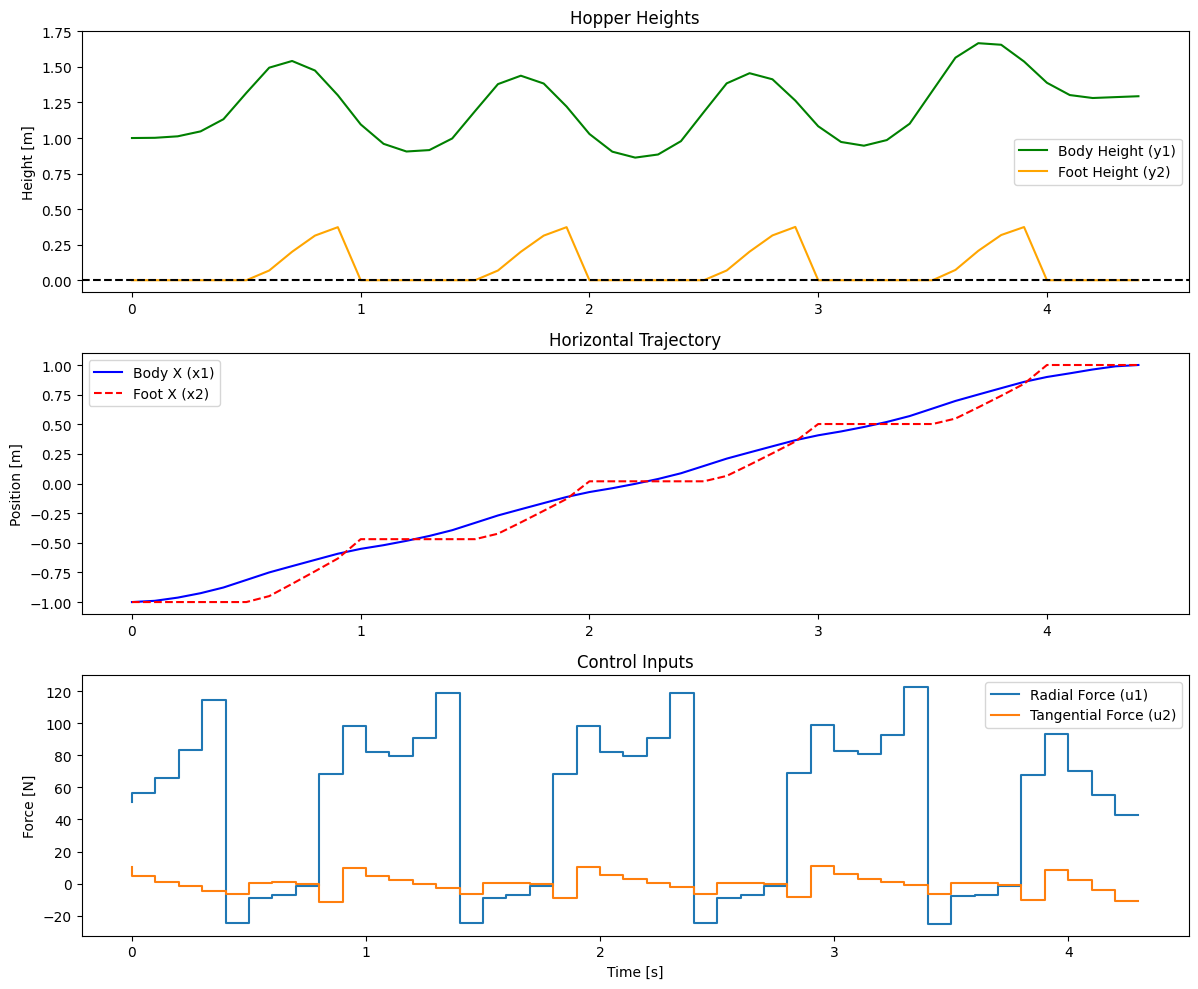

In [ ]:
# --- การ Plot ผลลัพธ์ ---
plt.figure(figsize=(12, 10))

# Plot 1: Vertical Position (Height)
plt.subplot(3, 1, 1)
plt.plot(time_axis, xtraj_sol[1, :], 'g-', label='Body Height (y1)')
plt.plot(time_axis, xtraj_sol[3, :], 'orange', label='Foot Height (y2)')
plt.axhline(0, color='black', linestyle='--')
plt.title('Hopper Heights')
plt.ylabel('Height [m]')
plt.legend()

# Plot 2: Horizontal Position
plt.subplot(3, 1, 2)
plt.plot(time_axis, xtraj_sol[0, :], 'b-', label='Body X (x1)')
plt.plot(time_axis, xtraj_sol[2, :], 'r--', label='Foot X (x2)')
plt.title('Horizontal Trajectory')
plt.ylabel('Position [m]')
plt.legend()

# Plot 3: Control Inputs (Forces)
plt.subplot(3, 1, 3)
plt.step(time_axis[:-1], utraj_sol[0, :], label='Radial Force (u1)')
plt.step(time_axis[:-1], utraj_sol[1, :], label='Tangential Force (u2)')
plt.title('Control Inputs')
plt.ylabel('Force [N]')
plt.xlabel('Time [s]')
plt.legend()

plt.tight_layout()
plt.show()

### Simulate Animation

#### Start MeshCat Session

สร้าง instance ของ visualizer และพิมพ์ URL เพื่อเปิดดู scene ใน browser

In [ ]:
# --- เริ่มต้น Visualizer ---
vis = meshcat.Visualizer()
print(f"MeshCat Visualizer link: {vis.url()}")

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7000/static/
MeshCat Visualizer link: http://127.0.0.1:7000/static/


#### Robot Geometry Definition

กำหนดขนาดทรงกลมของ body/foot และจุดแทนขา จากนั้นตั้ง material/สี และปรับพื้นหลัง

แนวคิดการแสดงขาใช้จุดหลายจุดตามแนวเส้นเชื่อม body-foot เพื่อความง่ายและประสิทธิภาพการเรนเดอร์

<div align="center">
<img src="meshcat model.png" width=700 />
</div>
<div align="center">
รูปที่ 3 meshcat model
</div>

In [ ]:
# --- ตั้งค่า Geometry (สร้างหุ่นจำลอง) ---
r_body = 0.2
r_foot = 0.1
r_leg = 0.05
n_leg = 30 # จำนวนจุดบนขา (ลดลงจาก 100 เพื่อความลื่นไหลใน Python)

# สร้าง Body (สีเขียว)
vis["body"].set_object(geo.Sphere(r_body),
                        geo.MeshPhongMaterial(color=0x00ff00, opacity=1.0))

# สร้าง Foot (สีส้ม)
vis["foot"].set_object(geo.Sphere(r_foot),
                        geo.MeshPhongMaterial(color=0xffa500, opacity=1.0))

# สร้าง Leg (สร้างเป็นกลุ่มของจุดเพื่อความง่าย)
for i in range(n_leg):
    vis[f"leg/p{i}"].set_object(geo.Sphere(r_leg),
                                    geo.MeshPhongMaterial(color=0x000000))

# กำหนดค่าพื้นฐานให้กล้องและพื้นหลัง
# vis["/Background"].set_property("top_color", [1, 1, 1])
# vis["/Background"].set_property("bottom_color", [1, 1, 1])

แปลงพิกัด 2D เป็น 3D:
$
(x,y)\rightarrow(x,0,z)
$
อัปเดตตำแหน่ง body และ foot ทุกเวลา และสร้าง leg points ด้วย linear interpolation:
$
\mathbf{p}_{leg}=(1-\alpha)\mathbf{p}_{body}+\alpha\mathbf{p}_{foot},\quad \alpha\in[0,1]
$
หน่วงเวลา $\Delta t=h$ ให้ความเร็วเล่นสอดคล้องกับ simulation

In [ ]:
def visualize_hopper(x_sol, h):
    print("Playing animation...")

    # วนลูปเพื่อแสดงผล (Simulation Playback)
    for t in range(x_sol.shape[1]):
        p_body = np.array([x_sol[0, t], 0.0, x_sol[1, t]])
        p_foot = np.array([x_sol[2, t], 0.0, x_sol[3, t]])

        # เลื่อนตำแหน่ง Body และ Foot (บวกค่า z_shift เพื่อไม่ให้จมพื้น)
        z_shift = np.array([0, 0, r_foot])
        vis["body"].set_transform(tf.translation_matrix(p_body + z_shift))
        vis["foot"].set_transform(tf.translation_matrix(p_foot + z_shift))

        # คำนวณตำแหน่งขา (Linear Interpolation ระหว่าง Body กับ Foot)
        for i in range(n_leg):
            alpha = i / (n_leg - 1)
            p_leg = (1 - alpha) * p_body + alpha * p_foot
            vis[f"leg/p{i}"].set_transform(tf.translation_matrix(p_leg + z_shift))

        # หน่วงเวลาให้ตรงกับค่า h (Time Step) ที่เราตั้งไว้
        time.sleep(h)

เรียกฟังก์ชันด้วยผลลัพธ์ $\mathbf{X}^\star$ และ time step $h$ เพื่อแสดงการเคลื่อนที่แบบ time-accurate playback

In [ ]:
visualize_hopper(xtraj_sol, h)

Playing animation...


### Conclusion
Project นี้ประสบความสำเร็จในการประยุกต์ใช้เทคนิค Nonlinear Programming (NLP) ร่วมกับระบบ Automatic Differentiation (JAX) เพื่อคำนวณหาแนวทางการเคลื่อนที่และแรงควบคุมที่เหมาะสมที่สุดสำหรับหุ่นยนต์ขาเดียวในระนาบ 2 มิติ แบบจำลองสามารถจัดการกับสภาวะไฮบริด (Hybrid Dynamics) ระหว่างช่วงสัมผัสพื้น (Stance) และช่วงลอยตัว (Flight) ได้อย่างมีประสิทธิภาพ โดยผลลัพธ์ที่ได้สอดคล้องกับข้อจำกัดทางกายภาพและเป้าหมายการเคลื่อนที่ที่กำหนดไว้

ความสำเร็จของการหาค่าที่เหมาะสมที่สุดยืนยันได้จากค่า Total Cost ($J$) ที่ลดลงจนเข้าสู่จุดที่เหมาะสมที่สุด (Optimal Solution) ตามสมการ:$$J_{final} = \sum_{k=0}^{N_t-1} L(x_k, u_k) \approx \text{113.928}$$โดยที่หุ่นยนต์สามารถรักษาสมดุลและปฏิบัติตามข้อจำกัดความยาวขา (Leg Length Constraint) ได้ตลอดช่วงเวลา $T_{final} = 4.4$ วินาที:$$0.5^2 \le \|r_{body,k} - r_{foot,k}\|^2 \le 1.5^2, \quad \forall k \in \{0, \dots, N_t\}$$

**ข้อค้นพบ**
- ประสิทธิภาพของ JAX: การใช้ jax.grad และ jax.jacobian ช่วยลดความผิดพลาดในการคำนวณอนุพันธ์ด้วยมือ และเพิ่มความเร็วในการประมวลผลของ Solver ได้อย่างมหาศาล
- พฤติกรรมการควบคุม: จากกราฟ $u_1$ (Radial) และ $u_2$ (Tangential) พบว่าระบบเลือกที่จะสร้างแรงดันสูงสุดในช่วงก่อนการ Take-off เพื่อเปลี่ยนพลังงานจลน์เป็นแรงส่งในแนววิถีโค้งพาราโบลา

**ข้อจำกัดและแนวทางการพัฒนาต่อ**
แม้ว่าแบบจำลองจะทำงานได้ดีในระบบจำลอง แต่ยังมีประเด็นที่ต้องพัฒนาหากนำไปใช้กับหุ่นยนต์จริง
- Model Mismatch: ในสภาวะจริงจะมีแรงเสียดทานและแรงต้านอากาศที่ไม่ได้ถูกคิดในสมการ $\ddot{r} = \frac{1}{m}u - g$
- Computation Time: การแก้ปัญหา NLP ทั้งเส้นทางใช้เวลาเกินกว่าจะทำ Real-time Control ดังนั้นควรพัฒนาต่อยอดไปสู่ระบบ Model Predictive Control (MPC) ที่คำนวณในช่วงสั้นๆ (Short Horizon) แทน

### For Implementation
การนำแบบจำลองจาก Trajectory Optimization ไปใช้กับหุ่นยนต์จริง Hardware Implementation

**เปลี่ยนจาก Offline Optimization เป็น Real-time Control**
- ในโปรเจกต์นี้ คำนวณเส้นทางทั้งเส้นครั้งเดียว แต่หุ่นยนต์จริงต้องปรับตัวตลอดเวลาวิธีทำ ต้องใช้แนวคิด Model Predictive Control (MPC) โดยการรัน Optimization สั้นๆ ซ้ำๆ ทุกๆ 10-50 มิลลิวินาที (Receding Horizon) เพื่อให้หุ่นยนต์แก้ทางได้ทันเมื่อเกิดแรงรบกวน

**สร้าง State Estimator (ส่วนรับรู้สถานะ)**
- ในโปรเจกต์นี้ เราสมมติว่ารู้ค่า $x, y, v$ ที่แม่นยำ แต่หุ่นยนต์จริงรู้แค่ค่าจากเซนเซอร์ ติดตั้ง IMU (วัดมุมและความเร่ง) และ Encoders (วัดระยะยืดขาและมุมสะโพก) จากนั้นใช้ Extended Kalman Filter (EKF) เพื่อรวมข้อมูลเซนเซอร์มาเป็นค่าสถานะ $x$ ที่แม่นยำ

**จัดการเรื่อง Actuator Dynamics**
- ในแบบจำลอง $u$ คือแรงที่เกิดขึ้นทันที แต่ในเครื่องจักรจริง มอเตอร์มีความหน่วงและมีขีดจำกัดของกระแสไฟ ต้องทำ Low-level Control เพื่อให้มอเตอร์จ่ายแรงได้ใกล้เคียงกับค่า $u$ ที่ Optimization คำนวณออกมา


##### ปัญหาที่ต้องพบและแนวทางแก้ไข (Challenges & Solutions)

ปัญหาที่อาจจะพบเจอ หากต้อง Implement กับหุ่นยนต์จริง

| ปัญหา (Challenges) | สาเหตุ (Causes) | แนวทางแก้ไข (Solutions) |
| --- | --- | --- |
| Model Mismatch (หุ่นยนต์ไม่เคลื่อนที่ตามกราฟ) | ค่า $m, l, g$ ใน Code ไม่ตรงกับหุ่นยนต์จริง 100% หรือมีแรงเสียดทาน (Friction) ที่ไม่ได้คิดไว้ทำ | System Identification โดยการทดลองเหวี่ยงขาจริงๆแล้วเก็บข้อมูลมาปรับจูนค่าพารามิเตอร์ในแบบจำลองให้ใกล้เคียงความจริงที่สุด |
| Latency & Computation Time (คอขวดที่ความเร็วการคำนวณ) | Ipopt อาจคำนวณช้าเกินกว่าที่จะรันใน Control Loop (เช่น 100Hz) | 1. ใช้ Warm-start (เอาคำตอบของรอบที่แล้วมาเป็นจุดเริ่มของรอบใหม่) 2. ใช้ Library ที่เร็วกว่าเช่น OSQP หรือ Acados แทน Ipopt 3. ลดความซับซ้อนของ Model ลง |
| Impact & Ground Contact (การชนพื้นแรงเกินไป) | แบบจำลองการชนใน Code (Inelastic Collision) อาจรุนแรงเกินไปจน Hardware พัง | ใช้ Impedance Control (จำลองให้ขาเป็นสปริง) ในจังหวะที่เท้าจะแตะพื้น เพื่อลดแรงกระแทก (Landing Buffer) |
| Measurement Noise (ค่าสถานะแกว่ง) | เซนเซอร์ IMU มีความไวต่อแรงสั่นสะเทือนออกแบบ | Low-pass Filter หรือปรับจูน Covariance ใน Kalman Filter เพื่อกรองสัญญาณรบกวนก่อนส่งเข้า Controller |


<div align="center">
<img src="Real_Implement.png" width=700 />
</div>
<div align="center">
รูปที่ 4 Hopper robot
</div>

### Experimental development

ผู้จัดทำได้ทดลองอัปเกรดแบบจำลอง Hopper จาก 2 มิติ (2D) เป็น 3 มิติ (3D) ซึ่งปรับเปลี่ยนโครงสร้างทางคณิตศาสตร์หลักๆ 4 ส่วน คือ จำนวนตัวแปร State/Input, ทิศทางของเวกเตอร์ (เปลี่ยน แกน Y เป็นแนวดิ่ง $\rightarrow$ แกน Z เป็นแนวดิ่ง), Rotation Matrix สำหรับ 3D และเงื่อนไขการชนพื้น (Constraints)

ส่วนนี้กำหนดปัญหาเชิงเวลาต่อเนื่องในรูปไม่เชิงเส้นด้วยการ discretize เวลา:
$
N_t=\left\lceil \frac{T_{final}}{h}\right\rceil + 1,\quad t_k = kh
$
โดยกำหนดมิติ
$
N_x=12 (จาก 8),\quad N_u=3 (จาก 2)
$
และพารามิเตอร์เชิงกายภาพ $g,m_1,m_2,l_{min},l_{max}$

Trajectory อ้างอิงหลัก:
$
z_{body,ref}(k)=1+0.5\sin\!\left(\frac{2\pi}{10}k\right)
$
พร้อมการเคลื่อนที่เชิงเส้นของ $x,y$

In [ ]:
Nx, Nu = 12, 3   # เปลี่ยนเป็น 12 States (Pos 3+3, Vel 3+3) และ 3 Inputs (แรง 3 แกน)
Tfinal, h = 4.4, 0.1
Nm = 5
Nt = int(np.ceil(Tfinal/h) + 1)
Nmodes = int(np.ceil(Nt/Nm))

g, m1, m2 = 9.81, 5.0, 1.0
l_min, l_max = 0.5, 1.5

# Reference Trajectory ใน 3D
ref_times = jnp.linspace(0, Tfinal, Nt)
xref = jnp.zeros((Nx, Nt))

# Body Position: วิ่งไปข้างหน้าตามแกน x, แกน y=0, กระโดดบนแกน z
xref = xref.at[0, :].set(jnp.linspace(-1.0, 1.0, Nt))  # x body
xref = xref.at[1, :].set(jnp.linspace(-1.0, 1.0, Nt))                          # y body
xref = xref.at[2, :].set(1.0 + 0.5 * jnp.sin(2 * jnp.pi / 10.0 * jnp.arange(Nt))) # z body (แนวดิ่ง)

# Foot Position
xref = xref.at[3, :].set(jnp.linspace(-1.0, 1.0, Nt))  # x foot
xref = xref.at[4, :].set(jnp.linspace(-1.0, 1.0, Nt))                          # y foot
xref = xref.at[5, :].set(0.0)                          # z foot

# Set velocities (ความเร็วอ้างอิงเฉพาะแกน x)
vx_ref = 2.0 / Tfinal
xref = xref.at[6, 1:-1].set(vx_ref)  # vx body
xref = xref.at[9, 1:-1].set(vx_ref)  # vx foot

# uref: แรงต้านแรงโน้มถ่วงในแกนแกนหลักขา, อีก 2 แกนเป็น 0
uref = jnp.array([m1 * g, 0.0, 0.0])

#### 3D Hybrid Dynamics

นิยามสถานะ:
$
\mathbf{x}=\begin{bmatrix}\mathbf{r}_1\\ \mathbf{r}_2\\ \mathbf{v}\end{bmatrix},
\quad \mathbf{r}_1,\mathbf{r}_2\in\mathbb{R}^3,\ \mathbf{v}\in\mathbb{R}^6
$
เวกเตอร์หน่วยแนวขา:
$
\mathbf{l}=\frac{\mathbf{r}_1-\mathbf{r}_2}{\|\mathbf{r}_1-\mathbf{r}_2\|}
$
สร้าง basis ตั้งฉาก $(\mathbf{l},\mathbf{n}_1,\mathbf{n}_2)$ และ
$
\mathbf{R}=[\mathbf{l}\ \mathbf{n}_1\ \mathbf{n}_2]
$
การแยกแรงจากขาไปยังบอดี้ ต้องใช้ Cross Product หาเวกเตอร์ที่ตั้งฉากกับขาอีก 2 แกน ($n_1, n_2$) เพื่อสร้างเป็น Rotation Matrix (R) ขนาด $3 \times 3$ แทนเมทริกซ์ 2D เดิม

พลวัต:
$
\dot{\mathbf{x}}=
\begin{bmatrix}
\mathbf{v}\\
\mathbf{g}_{mode}+\mathbf{M}^{-1}\mathbf{B}_{mode}\mathbf{u}
\end{bmatrix}
$
โดย $\mathbf{B}_{mode}$ ต่างกันตาม stance/flight

In [ ]:
def get_3D_dynamics(x, u, mode):
    # ดึงค่าพิกัดความยาว 3 มิติ
    r1, r2, v = x[0:3], x[3:6], x[6:12]
    dist = jnp.linalg.norm(r1 - r2)
    l_vec = (r1 - r2) / dist  # Unit vector แนวขา

    # สร้าง Basis Vectors สำหรับแกนที่เหลือ (n1, n2) ที่ตั้งฉากกับ l_vec
    z_vec = jnp.array([0.0, 0.0, 1.0])
    x_vec = jnp.array([1.0, 0.0, 0.0])
    # ป้องกัน Singularity หากขาชี้ขนานกับแกน z พอดี
    ref_vec = jnp.where(jnp.abs(l_vec[2]) > 0.99, x_vec, z_vec)

    n1 = jnp.cross(l_vec, ref_vec)
    n1 = n1 / jnp.linalg.norm(n1)
    n2 = jnp.cross(l_vec, n1)
    n2 = n2 / jnp.linalg.norm(n2)

    # Rotation matrix เปลี่ยนจาก Local Leg Frame ไปยัง World Frame
    R = jnp.column_stack([l_vec, n1, n2])

    # B matrix (6x3) สำหรับกระจายแรงไปที่ Body และ Foot
    B_flight = jnp.vstack([R, -R])
    B_stance = jnp.vstack([R, jnp.zeros((3, 3))])
    B = jax.lax.cond(mode % 2 == 0, lambda _: B_stance, lambda _: B_flight, operand=None)

    # มวล 3 มิติ
    m_inv = jnp.diag(jnp.array([1/m1, 1/m1, 1/m1, 1/m2, 1/m2, 1/m2]))

    # Gravity ใน 3D (Z เป็นแนวดิ่ง)
    gravity_flight = jnp.array([0.0, 0.0, -g, 0.0, 0.0, -g])
    gravity_stance = jnp.array([0.0, 0.0, -g, 0.0, 0.0, 0.0])
    gravity = jax.lax.cond(mode % 2 == 0, lambda _: gravity_stance, lambda _: gravity_flight, operand=None)

    vdot = gravity + m_inv @ (B @ u)
    return jnp.concatenate([v, vdot])

Runge–Kutta 4th order

In [ ]:
def rk4_step_3D(x, u, mode):
    f = lambda _x: get_3D_dynamics(_x, u, mode)
    k1 = f(x)
    k2 = f(x + 0.5 * h * k1)
    k3 = f(x + 0.5 * h * k2)
    k4 = f(x + h * k3)
    return x + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

(หมายเหตุ: ฟังก์ชัน unpack_z และ objective สามารถใช้โค้ดเดิมได้เลยเนื่องจากเขียนในรูปแบบ Vectorized รองรับขนาด $N_x$ ใหม่แบบอัตโนมัติแล้ว)

**อัปเดตฟังก์ชัน Constraints** (ดัชนีแกน Z และความเร็ว)ต้องแก้ Index ให้สอดคล้องกับพิกัด $Z$ (แทนที่ค่า $Y$) และเวกเตอร์ความเร็วที่มี 3 มิติ

ข้อจำกัดหลัก:

1. Initial/terminal:
$
\mathbf{x}_0=\mathbf{x}_{ref,0},\quad \mathbf{x}_{N_t-1}=\mathbf{x}_{ref,N_t-1}
$

2. Dynamics:
$
\mathbf{x}_{k+1}-\Phi_h(\mathbf{x}_k,\mathbf{u}_k,mode_k)=\mathbf{0}
$

3. Stance contact:
$
z_{foot}(k)=0 \quad (\text{เมื่ออยู่โหมด stance})
$

4. Leg-length bounds:
$
l_{min}^2 \le \|\mathbf{r}_{1,k}-\mathbf{r}_{2,k}\|^2 \le l_{max}^2
$

และมี inelastic jump map ช่วงจบ flight เพื่อรีเซ็ตความเร็วเท้า

In [ ]:
def constraints_3D(z):
    X, U = unpack_z(z)
    cons = []

    # 1. Initial & Terminal
    cons.append(X[:, 0] - xref[:, 0])
    cons.append(X[:, -1] - xref[:, -1])

    # 2. Dynamics & Stance
    for k in range(Nt - 1):
        mode = k // Nm
        is_last_step_of_flight = (mode % 2 != 0) and ((k+1) % Nm == 0)

        x_next_sim = rk4_step_3D(X[:, k], U[:, k], mode)

        # Inelastic collision jump map: เซ็ตความเร็วเท้าเป็น 0 (Index 9,10,11)
        if is_last_step_of_flight:
            x_next_sim = x_next_sim.at[9:12].set(0.0)

        cons.append(x_next_sim - X[:, k+1])

        # Stance constraint: foot z=0 (ให้ z คือแกนดิ่งใน index ที่ 5)
        if mode % 2 == 0:
            cons.append(jnp.array([X[5, k]]))

    # 3. Leg length bounds (ระยะห่าง 3 มิติ)
    for k in range(Nt):
        length_sq = jnp.sum((X[0:3, k] - X[3:6, k])**2)
        cons.append(jnp.array([length_sq]))

    return jnp.concatenate(cons)

ใช้ JAX คำนวณอนุพันธ์:
$
\nabla J(\mathbf{z}),\qquad
\mathbf{J}_c(\mathbf{z})=\frac{\partial \mathbf{c}}{\partial \mathbf{z}}
$
พร้อม `jit` เพื่อลดเวลาประมวลผลเมื่อ solver เรียกซ้ำจำนวนมาก

ปัญหา:
$
\min_{\mathbf{z}} J(\mathbf{z})
\quad \text{s.t.} \quad
\mathbf{c}_L \le \mathbf{c}(\mathbf{z}) \le \mathbf{c}_U
$

In [ ]:
# JAX Differentiation
jit_obj = jax.jit(objective)
jit_grad = jax.jit(jax.grad(objective))
jit_cons = jax.jit(constraints_3D)
jit_jac = jax.jit(jax.jacobian(constraints_3D))

ขนาด decision vector:
$
n_{nlp}=N_tN_x+(N_t-1)N_u
$

กำหนดขอบเขต constraints:
- Equality constraints: $c_L=c_U=0$
- Leg-length constraints: $[l_{min}^2,l_{max}^2]$

ต้องระบุช่วง index ของ leg constraints ให้ตรงกับลำดับ append ในฟังก์ชัน constraints

In [ ]:
# ตั้งค่า Bounds
n_nlp = Nt * Nx + (Nt - 1) * Nu
z0 = np.zeros(n_nlp) # ควรใช้ guess จาก xref

# คำนวณจำนวน Constraints เพื่อตั้งค่า Lower/Upper Bounds (cl, cu)
c_sample = jit_cons(z0)
m_nlp = len(c_sample)
cl = np.zeros(m_nlp)
cu = np.zeros(m_nlp)

# ปรับ bounds สำหรับ leg length (ช่วงท้ายของ constraints vector)
# ต้องนับ index ให้แม่นยำตามการ append ในฟังก์ชัน constraints
leg_cons_start_idx = m_nlp - Nt
cl[leg_cons_start_idx:] = l_min**2
cu[leg_cons_start_idx:] = l_max**2

สร้าง `Problem(...)` โดยส่ง:
- $n,m$
- callback object (objective, gradient, constraints, jacobian)
- variable bounds และ constraint bounds

รูปเชิงคณิตศาสตร์:
$
\mathbf{z}^\star=\arg\min_{\mathbf{z}}J(\mathbf{z})
\quad \text{s.t.}\quad
\mathbf{c}_L\le \mathbf{c}(\mathbf{z})\le \mathbf{c}_U
$

In [ ]:
prob = Problem(
    n=n_nlp,
    m=m_nlp,
    problem_obj=HopperProblem(),
    lb=-np.inf * np.ones(n_nlp),
    ub=np.inf * np.ones(n_nlp),
    cl=cl,
    cu=cu
)

#### Initial Guess

สร้างค่าเริ่มต้นจาก reference + Gaussian noise:
$
\mathbf{X}^{(0)}=\mathbf{X}_{ref}+\epsilon_x,\qquad
\mathbf{U}^{(0)}=\mathbf{U}_{ref}+\epsilon_u
$
และ pack เป็น $\mathbf{z}_0$

In [ ]:
xguess = np.array(xref) + 0.1 * np.random.randn(Nx, Nt)
uguess = np.tile(uref.reshape(-1, 1), (1, Nt-1)) + 0.1 * np.random.randn(Nu, Nt-1)

z0_list = []
for k in range(Nt - 1):
    z0_list.append(xguess[:, k])
    z0_list.append(uguess[:, k])
z0_list.append(xguess[:, -1])

z0 = np.concatenate(z0_list)

#### Solver Execution

In [ ]:
# กำหนดค่าพารามิเตอร์สำหรับ Ipopt
prob.add_option('tol', 1e-6)
prob.add_option('constr_viol_tol', 1e-6)
prob.add_option('max_iter', 1000)
prob.add_option('hessian_approximation', 'limited-memory') # ใช้ L-BFGS แทนการหา Hessian จริง

print("Starting solver...")
z_sol_3D, info = prob.solve(z0)

print(f"Solver Status: {info['status_msg']}")

Starting solver...
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:   387072
Number of nonzeros in inequality constraint Jacobian.:    30240
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      672
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      576
Total number of inequality constraints...............:       45
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:       45
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.4908690e+00 6.05e+00 3.05e-01   0.0 0.00e+00    - 

(หมายเหตุ: ฟังก์ชัน post_process สามารถใช้โค้ดเดิมได้เลยเนื่องจากเขียนในรูปแบบ Vectorized รองรับขนาด $N_x$ ใหม่แบบอัตโนมัติแล้ว)

In [ ]:
xtraj_sol_3D, utraj_sol_3D = post_process(z_sol_3D)
time_axis = np.linspace(0, Tfinal, Nt)

#### Result Plot

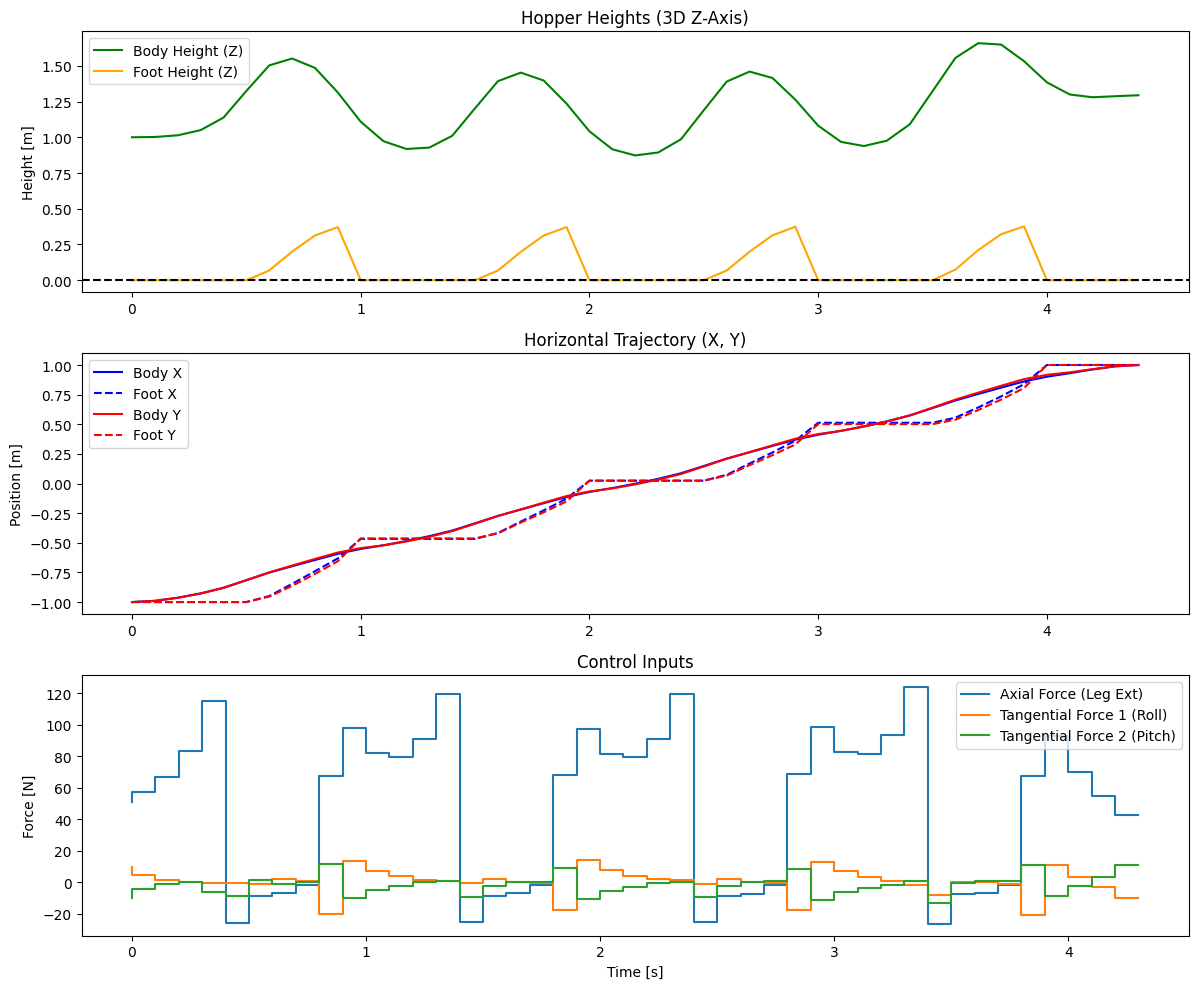

In [ ]:
# --- การ Plot ผลลัพธ์ ---
plt.figure(figsize=(12, 10))

# Plot 1: Vertical Position (Z Height)
plt.subplot(3, 1, 1)
plt.plot(time_axis, xtraj_sol_3D[2, :], 'g-', label='Body Height (Z)')
plt.plot(time_axis, xtraj_sol_3D[5, :], 'orange', label='Foot Height (Z)')
plt.axhline(0, color='black', linestyle='--')
plt.title('Hopper Heights (3D Z-Axis)')
plt.ylabel('Height [m]')
plt.legend()

# Plot 2: Horizontal Position (X-Y)
plt.subplot(3, 1, 2)
plt.plot(time_axis, xtraj_sol_3D[0, :], 'b-', label='Body X')
plt.plot(time_axis, xtraj_sol_3D[3, :], 'b--', label='Foot X')
plt.plot(time_axis, xtraj_sol_3D[1, :], 'r-', label='Body Y')
plt.plot(time_axis, xtraj_sol_3D[4, :], 'r--', label='Foot Y')
plt.title('Horizontal Trajectory (X, Y)')
plt.ylabel('Position [m]')
plt.legend()

# Plot 3: Control Inputs (3D Forces)
plt.subplot(3, 1, 3)
plt.step(time_axis[:-1], utraj_sol_3D[0, :], label='Axial Force (Leg Ext)')
plt.step(time_axis[:-1], utraj_sol_3D[1, :], label='Tangential Force 1 (Roll)')
plt.step(time_axis[:-1], utraj_sol_3D[2, :], label='Tangential Force 2 (Pitch)')
plt.title('Control Inputs')
plt.ylabel('Force [N]')
plt.xlabel('Time [s]')
plt.legend()

plt.tight_layout()
plt.show()

#### Animation Function
คำนวณตำแหน่งจุดขาด้วย interpolation:
$
\mathbf{p}_{leg}(\alpha)=(1-\alpha)\mathbf{p}_{body}+\alpha\mathbf{p}_{foot},\quad \alpha\in[0,1]
$
อัปเดต object transform ตามเวลา และหน่วงด้วย $\Delta t=h$ เพื่อให้ playback สอดคล้อง simulation step

In [ ]:
def visualize_3Dhopper(x_sol, h):
    print("Playing animation...")

    # วนลูปเพื่อแสดงผล (Simulation Playback)
    for t in range(x_sol.shape[1]):
        p_body = x_sol[0:3, t]
        p_foot = x_sol[3:6, t]

        # เลื่อนตำแหน่ง Body และ Foot (บวกค่า z_shift เพื่อไม่ให้จมพื้น)
        z_shift = np.array([0, 0, r_foot])
        vis["body"].set_transform(tf.translation_matrix(p_body + z_shift))
        vis["foot"].set_transform(tf.translation_matrix(p_foot + z_shift))

        # คำนวณตำแหน่งขา (Linear Interpolation ระหว่าง Body กับ Foot)
        for i in range(n_leg):
            alpha = i / (n_leg - 1)
            p_leg = (1 - alpha) * p_body + alpha * p_foot
            vis[f"leg/p{i}"].set_transform(tf.translation_matrix(p_leg + z_shift))

        # หน่วงเวลาให้ตรงกับค่า h (Time Step) ที่เราตั้งไว้
        time.sleep(h)

In [ ]:
visualize_3Dhopper(xtraj_sol_3D, h)

Playing animation...


### Reference

1. Z. Manchester et.al. [16-745 Optimal Control & Reinforcement Learning,
Course materials](https://optimalcontrol.ri.cmu.edu/#learning-resources), Carnegie Mellon University. 2025.